# BAB V — Implementasi dan Pengujian
## Identifikasi Biometrik Telapak Tangan Menggunakan Fitur Garis Telapak Tangan

Notebook ini mengimplementasikan seluruh alur pada Bab V secara berurutan:

1. **5.1 Proses ROI** — preprocessing-1 (grayscale + hapus background), preprocessing-2 (Gaussian blur + Otsu thresholding), preprocessing-3 (erosi + kontur), serta perhitungan ROI (FFT, minima & rotasi).
2. **5.2 Ekstraksi Fitur** — CNN (EfficientNet) dan kombinasi CNN + LBP.
3. **5.3 Pengujian Sistem** — evaluasi model dengan confusion matrix (akurasi, precision, recall, F1-score).

> Catatan: setiap sel kode diberi komentar yang menjelaskan fungsi, nilai parameter/variabel, dan teknik yang dipakai (mis. jenis augmentasi).

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
# 5.1 Implementasi Proses ROI

Tujuan tahap ini adalah memperoleh citra **ROI (Region of Interest)** dari gambar telapak tangan. Proses melibatkan 3 tahap preprocessing yang kemudian dilanjutkan perhitungan untuk mendapatkan ROI.

## 5.1.1 Import Library (Proses ROI)

In [2]:
!pip install "rembg==2.0.59" "onnxruntime==1.19.2"

In [3]:
# === Library untuk proses ROI ===
import os                              # membaca / menulis file
import csv                             # membaca / menulis file CSV
import numpy as np                     # operasi numerik yang efisien untuk pemrosesan data
import cv2                             # OpenCV: visi komputer & pemrosesan gambar
from PIL import Image                  # Pillow: membuka, memanipulasi, menyimpan gambar
from matplotlib import pyplot as plt   # visualisasi grafik (interaktif & statis)
from rembg import remove               # menghapus latar belakang gambar secara otomatis


# Helper kecil untuk menampilkan gambar grayscale dengan rapi
def show(img):
    """Menampilkan satu citra (grayscale) menggunakan matplotlib."""
    plt.imshow(img, cmap="gray")
    plt.axis("off")

## 5.1.2 Preprocessing-1 (Grayscale + Hapus Background)

Langkah: muat gambar → ambil dimensi → resize ke **480 x 640** → konversi ke **grayscale** → hapus background dengan `rembg`.

In [4]:
def preprocessing_1(image_path):
    """Preprocessing-1: resize, grayscale, dan hapus background.
    Mengembalikan output_image (PIL Image) hasil penghapusan background."""
    # Memuat gambar dari path
    img = cv2.imread(image_path)

    # Periksa apakah gambar berhasil dimuat
    if img is None:
        raise ValueError(f"Gambar tidak dapat dimuat. Pastikan path benar: {image_path}")

    # Mendapatkan tinggi (h) dan lebar (w) gambar asli
    h, w = img.shape[:2]

    # Mengubah ukuran gambar menjadi 480 x 640 piksel (interpolasi kubik agar halus)
    img_resized = cv2.resize(img, dsize=(480, 640), interpolation=cv2.INTER_CUBIC)

    # Mengubah gambar ke skala abu-abu (grayscale)
    img_resized = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

    # Membuka gambar sebagai input untuk rembg
    input_image = Image.fromarray(img_resized)

    # Menghapus background dari gambar tangan secara otomatis
    output_image = remove(input_image)

    return output_image


# Contoh pemakaian (ganti dengan path gambar telapak tangan Anda):
# image_path = "dataset/sample_hand.jpg"
# output_image = preprocessing_1(image_path)
# show(np.array(output_image)); plt.title("Hasil Preprocessing-1"); plt.show()

## 5.1.3 Preprocessing-2 (Gaussian Blur + Otsu Thresholding)

Hasil preprocessing-1 dikonversi ke array OpenCV, tinggi gambar diperluas **+160 px** (80 atas + 80 bawah), lalu di-blur dengan **Gaussian Blur kernel 5x5** dan di-threshold dengan **Otsu**.

In [5]:
def preprocessing_2(output_image):
    """Preprocessing-2: Gaussian Blur + Otsu thresholding.
    Mengembalikan citra biner `th`."""
    # Konversi gambar PIL (hasil rembg) ke array OpenCV
    img_original = np.array(output_image)

    # Jika gambar belum grayscale (punya 3 channel), konversikan ke grayscale
    if len(img_original.shape) == 3:
        img_original = cv2.cvtColor(img_original, cv2.COLOR_RGB2GRAY)

    # Memperluas tinggi gambar sebanyak 160 piksel (80 di atas dan 80 di bawah)
    h, w = img_original.shape
    img = np.zeros((h + 160, w), np.uint8)   # kanvas hitam baru
    img[80:-80, :] = img_original            # tempel gambar asli di tengah

    # Menerapkan Gaussian Blur dengan kernel 5x5 (sigma=0 dihitung otomatis)
    blur = cv2.GaussianBlur(img, (5, 5), 0)

    # Menerapkan Otsu's thresholding -> menghasilkan citra biner (0 / 255)
    _, th = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    return img, th


# Contoh pemakaian:
# img, th = preprocessing_2(output_image)
# show(th); plt.title("Hasil Preprocessing-2 (Otsu)"); plt.show()

## 5.1.4 Preprocessing-3 (Erosi dan Kontur)

Menghitung **pusat massa** dari momen citra biner, melakukan **erosi** dengan kernel 3x3, mengambil **boundary** (tepi), lalu mencari & menggambar **kontur**.

In [6]:
def preprocessing_3(img, th, visualize=True):
    """Preprocessing-3: hitung pusat massa, erosi, boundary, dan kontur.
    Mengembalikan (cnt, x_c, y_c) untuk dipakai pada perhitungan ROI."""
    # Menghitung momen dari citra biner `th`
    M = cv2.moments(th)
    h, w = img.shape

    # Koordinat pusat massa (centroid) dari citra biner:
    #   m10 / m00 -> koordinat x ; m01 / m00 -> koordinat y
    #   m00 merepresentasikan total intensitas piksel
    x_c = M['m10'] // M['m00']
    y_c = M['m01'] // M['m00']

    plt.figure(figsize=(15, 5))
    plt.subplot(121)
    show(th)
    plt.plot(x_c, y_c, 'bx', markersize=10)   # tandai pusat massa

    # Kernel 3x3 berbentuk plus untuk operasi erosi
    kernel = np.array([[0, 1, 0],
                       [1, 1, 1],
                       [0, 1, 0]]).astype(np.uint8)

    # Operasi erosi pada citra biner (iterasi = 1)
    erosion = cv2.erode(th, kernel, iterations=1)

    # Boundary (tepi objek) = citra biner asli - hasil erosi
    boundary = th - erosion

    # Mencari kontur pada citra boundary:
    #   RETR_TREE          -> simpan semua kontur + hierarki penuh
    #   CHAIN_APPROX_NONE  -> simpan SEMUA titik kontur
    cnt, _ = cv2.findContours(boundary, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)

    # Ubah gambar grayscale ke BGR agar kontur bisa digambar berwarna
    img_c = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    cnt = cnt[0]   # ambil kontur pertama dari list kontur

    # Gambar kontur dengan warna merah (255,0,0), tebal garis 2
    img_cnt = cv2.drawContours(img_c, [cnt], 0, (255, 0, 0), 2)

    if visualize:
        plt.subplot(122)
        plt.plot(x_c, y_c, 'bx', markersize=10)
        show(img_cnt)
        plt.tight_layout()
        plt.show()

    return cnt, x_c, y_c

## 5.1.5 Perhitungan ROI — Analisis Frekuensi & Rotasi (FFT)

Kontur dianalisis dengan **Fourier Transform** untuk memisahkan frekuensi tinggi (noise) dan rendah (fitur utama). Fungsi jarak Euclidean (ED function) dihitung dari setiap titik kontur ke pusat massa, lalu di-*low-pass filter* dengan **cutoff = 15**.

In [7]:
def hitung_ed_function(cnt, x_c, y_c, cutoff=15):
    """Menghitung fungsi jarak Euclidean (ED) + low-pass filtering via FFT.
    Mengembalikan (cnt, dist_c, dist_c_1)."""
    # Susun koordinat kontur sebagai array 2D: kolom 0 = x, kolom 1 = y
    cnt = cnt.reshape(-1, 2)

    # Indeks titik kontur dengan jumlah koordinat (x + y) terkecil -> titik kiri-atas
    left_id = np.argmin(cnt.sum(-1))

    # Putar urutan kontur agar dimulai dari titik kiri-atas
    cnt = np.concatenate([cnt[left_id:, :], cnt[:left_id, :]])

    # Fungsi jarak Euclidean: jarak tiap titik kontur ke pusat massa (x_c, y_c)
    dist_c = np.sqrt(np.square(cnt - [x_c, y_c]).sum(-1))

    # Fast Fourier Transform (FFT) dari fungsi jarak
    f = np.fft.rfft(dist_c)

    # cutoff = 15 -> ambang frekuensi; komponen di atasnya dinolkan (low-pass filter)
    f_new = np.concatenate([f[:cutoff], 0 * f[cutoff:]])

    # Inverse FFT -> fungsi jarak yang halus (hanya frekuensi rendah)
    dist_c_1 = np.fft.irfft(f_new)

    # Visualisasi perbandingan fungsi jarak asli vs hasil rekonstruksi frekuensi rendah
    plt.figure(figsize=(15, 5))
    plt.grid()
    plt.plot(dist_c, label='Original ED function', color='r', linewidth='3', linestyle='--')
    plt.plot(dist_c_1, label='Low frequency reconstruction', color='b', linestyle='-')
    plt.legend()
    plt.show()

    return cnt, dist_c, dist_c_1

### Menentukan Minima dan Rotasi ROI

Titik **minima** dicari dari perubahan tanda turunan fungsi jarak. Dua minima terakhir (`v1`, `v2`) dipakai untuk menghitung sudut rotasi `theta`, citra diluruskan, lalu kotak **ROI** digambar dari koordinat sudut (ux, uy) dan (lx, ly).

In [8]:
def tentukan_roi(img, cnt, dist_c_1):
    """Mencari titik minima, menghitung rotasi, dan menggambar kotak ROI."""
    # Turunan pertama dari fungsi jarak halus untuk menemukan titik ekstrim
    derivative = np.diff(dist_c_1)

    # Perubahan tanda turunan -> menandai posisi titik ekstrim (minima/maxima)
    sign_change = np.diff(np.sign(derivative)) / 2

    # Ambil titik-titik kontur pada perubahan tanda positif (minima)
    minimas = cnt[np.where(sign_change > 0)[0]]

    # Dua titik minima yang dipakai untuk menghitung rotasi (minima terakhir & ke-3 dari belakang)
    v1, v2 = minimas[-1], minimas[-3]

    plt.figure(figsize=(15, 5))
    plt.subplot(131)
    show(img)
    plt.plot(v1[0], v1[1], 'rx')
    plt.plot(v2[0], v2[1], 'bx')

    plt.subplot(132)
    # Sudut antara garis v1-v2 dan sumbu horizontal (dalam derajat)
    theta = np.arctan2((v2 - v1)[1], (v2 - v1)[0]) * 180 / np.pi
    print('The rotation of ROI is {:.02f}°'.format(theta))

    # Pusat rotasi = titik tengah antara v1 dan v2
    center = (int((v1[0] + v2[0]) // 2), int((v1[1] + v2[1]) // 2))

    # Matriks rotasi 2D (skala = 1) lalu putar gambar agar ROI lurus
    R = cv2.getRotationMatrix2D(tuple(center), theta, 1)
    h, w = img.shape
    img_r = cv2.warpAffine(img, R, (w, h))

    # Perbarui koordinat v1 & v2 sesuai rotasi
    v1 = (R[:, :2] @ v1 + R[:, -1]).astype(int)
    v2 = (R[:, :2] @ v2 + R[:, -1]).astype(int)
    plt.plot(v1[0], v1[1], 'rx')
    plt.plot(v2[0], v2[1], 'bx')
    show(img_r)

    # Koordinat sudut ROI: (ux, uy) kiri-atas dan (lx, ly) kanan-bawah
    ux = v1[0]
    uy = v1[1] + (v2 - v1)[0] // 3
    lx = v2[0]
    ly = v2[1] + 4 * (v2 - v1)[0] // 3

    # Gambar kotak ROI berwarna hijau (0,255,0)
    img_c = cv2.cvtColor(img_r, cv2.COLOR_GRAY2BGR)
    cv2.rectangle(img_c, (lx, ly), (ux, uy), (0, 255, 0), 2)
    plt.subplot(133)
    show(img_c)
    plt.tight_layout()
    plt.show()

    # Potong ROI akhir dari citra yang sudah diluruskan
    roi = img_r[uy:ly, ux:lx]
    return roi

### Pipeline ROI End-to-End

Menggabungkan seluruh tahap 5.1.2 – 5.1.5 menjadi satu fungsi agar mudah dipanggil per gambar.

In [9]:
def ekstrak_roi(image_path):
    """Pipeline lengkap: dari gambar tangan mentah -> citra ROI."""
    output_image = preprocessing_1(image_path)           # grayscale + hapus background
    img, th = preprocessing_2(output_image)              # Gaussian blur + Otsu
    cnt, x_c, y_c = preprocessing_3(img, th)             # erosi + kontur
    cnt, dist_c, dist_c_1 = hitung_ed_function(cnt, x_c, y_c, cutoff=15)  # FFT
    roi = tentukan_roi(img, cnt, dist_c_1)               # minima, rotasi, crop ROI
    return roi


# Contoh: roi = ekstrak_roi("dataset/sample_hand.jpg")
# show(roi); plt.title("Gambar ROI Tangan"); plt.show()

---
# 5.2 Implementasi Ekstraksi Fitur

Ekstraksi fitur memanfaatkan kemampuan **CNN** dalam mengekstraksi representasi visual citra. Diawali preprocessing (normalisasi ukuran, konversi warna, augmentasi), lalu citra dimasukkan ke arsitektur CNN.

## 5.2.0 Persiapan Dataset — Split Train / Val / Test

Dataset mentah tersusun sebagai `dataset_mentah/{nama_orang}/` (satu subfolder per orang = satu **kelas**). Sebelum dimuat, dataset perlu dibagi menjadi **train / val / test** sambil **mempertahankan struktur folder per kelas**, sehingga hasilnya:

```
dataset/
  train/<nama_orang>/*.jpg
  val/<nama_orang>/*.jpg
  test/<nama_orang>/*.jpg
```

Rasio default: **70% train, 15% val, 15% test**. Pembagian dilakukan **per orang** (stratified) agar setiap kelas terwakili di ketiga subset, dan `random.seed` dipakai supaya hasil split bisa direproduksi.

In [10]:
import os
import shutil
import random

# -----------------------------
# Konfigurasi split
# -----------------------------
SRC_DIR = "/content/drive/MyDrive/Skripsi/dataset_mentah"   # folder sumber: dataset_mentah/<nama_orang>/*.jpg
DST_DIR = "/content/drive/MyDrive/Skripsi/dataset_roi"          # folder tujuan: dataset/{train,val,test}/<nama_orang>/

TRAIN_RATIO = 0.70            # 70% data untuk training
VAL_RATIO   = 0.15            # 15% data untuk validasi
TEST_RATIO  = 0.15            # 15% data untuk testing (sisa)
SEED        = 42             # seed agar pembagian dapat direproduksi

# Ekstensi file gambar yang dianggap valid
IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

random.seed(SEED)

def split_dataset(src_dir=SRC_DIR, dst_dir=DST_DIR,
                  train_ratio=TRAIN_RATIO, val_ratio=VAL_RATIO, copy=True):
    """Membagi dataset_mentah/<nama_orang> menjadi train/val/test per kelas.
    copy=True -> menyalin file (data mentah tetap utuh); set False untuk memindahkan."""
    transfer = shutil.copy2 if copy else shutil.move

    # Iterasi tiap folder orang (kelas)
    persons = [d for d in sorted(os.listdir(src_dir))
               if os.path.isdir(os.path.join(src_dir, d))]
    print(f"Ditemukan {len(persons)} kelas (orang): {persons}")

    ringkasan = {}
    for person in persons:
        person_dir = os.path.join(src_dir, person)
        # Ambil semua file gambar milik orang ini
        images = [f for f in os.listdir(person_dir)
                  if f.lower().endswith(IMG_EXTS)]
        random.shuffle(images)   # acak agar pembagian tidak bias urutan file

        n = len(images)
        n_train = int(n * train_ratio)              # jumlah data train
        n_val   = int(n * val_ratio)                # jumlah data val
        # sisanya menjadi test (menghindari kehilangan file akibat pembulatan)
        splits = {
            "train": images[:n_train],
            "val":   images[n_train:n_train + n_val],
            "test":  images[n_train + n_val:],
        }

        # Salin/pindahkan ke dataset/<split>/<person>/
        for split_name, files in splits.items():
            out_dir = os.path.join(dst_dir, split_name, person)
            os.makedirs(out_dir, exist_ok=True)
            for f in files:
                transfer(os.path.join(person_dir, f), os.path.join(out_dir, f))

        ringkasan[person] = {k: len(v) for k, v in splits.items()}
        print(f"  {person}: total={n} -> "
              f"train={ringkasan[person]['train']}, "
              f"val={ringkasan[person]['val']}, "
              f"test={ringkasan[person]['test']}")

    return ringkasan


# Jalankan split (data mentah tetap aman karena default copy=True)
ringkasan = split_dataset()
print("\nSplit selesai. Struktur 'dataset/train|val|test/<nama_orang>/' siap dipakai.")

Ditemukan 28 kelas (orang): ['Abi Al Qhafari', 'Aldin Pramudya', 'Cahaya Indrasmara', 'Dewa Anggoro Mulianto', 'Dhana Reyhan', 'Fajar Cita Wibowo', 'Fauzan Habibi', 'Ikrar Budi Dharma', 'Ken Arya Rizkyka', 'MUHAMMAD HAIDAR SHAHAB', 'Marthalita Dwi', 'Muhamad Enrinal Zulhimar', 'Muhammad Ariq Pratama', 'Muhammad Gading', 'Muhammad Maul', 'Muhammad Ridho Habibie', 'Muhammad Tegar', 'Naufalsyah Falah Muhammad', 'Pahlevi Aulia', 'Ramadhani Wijaya', 'Razoub Ramadhan', 'Riski Jaya', 'Rizki Evan', 'Roziq Mahbubi', 'Sadam Firdaus Ubaidilah', 'Taufik Mulyawan', 'Trio Adhi Pamungkas', 'Wildan ihza mahbubi']
  Abi Al Qhafari: total=40 -> train=28, val=6, test=6
  Aldin Pramudya: total=40 -> train=28, val=6, test=6
  Cahaya Indrasmara: total=40 -> train=28, val=6, test=6
  Dewa Anggoro Mulianto: total=40 -> train=28, val=6, test=6
  Dhana Reyhan: total=40 -> train=28, val=6, test=6
  Fajar Cita Wibowo: total=40 -> train=28, val=6, test=6
  Fauzan Habibi: total=40 -> train=28, val=6, test=6
  Ikrar

> **Opsional — terapkan ROI dulu sebelum split.** Jika ingin melatih model pada citra **ROI** (bukan gambar tangan mentah), jalankan `ekstrak_roi()` dari Bagian 5.1 pada tiap gambar `dataset_mentah/<orang>/*.jpg`, simpan hasilnya ke folder sementara (mis. `dataset_roi/<orang>/`), lalu set `SRC_DIR = "dataset_roi"` pada sel split di atas.

## 5.2.1 Ekstraksi Fitur dengan CNN (EfficientNet)

Dataset dibagi menjadi **train / val / test**, dimuat dengan ukuran input **224x224** dan **batch size 32**. Augmentasi yang dipakai: **RandomFlip horizontal, RandomRotation(0.1), RandomZoom(0.1)**. Base model **EfficientNetB0** (transfer learning, bobot ImageNet, top layer dibuang). Hasil akurasi uji ≈ **94%**.

Found 784 files belonging to 28 classes.
Found 168 files belonging to 28 classes.
Found 168 files belonging to 28 classes.
Jumlah kelas: 28 -> ['Abi Al Qhafari', 'Aldin Pramudya', 'Cahaya Indrasmara', 'Dewa Anggoro Mulianto', 'Dhana Reyhan', 'Fajar Cita Wibowo', 'Fauzan Habibi', 'Ikrar Budi Dharma', 'Ken Arya Rizkyka', 'MUHAMMAD HAIDAR SHAHAB', 'Marthalita Dwi', 'Muhamad Enrinal Zulhimar', 'Muhammad Ariq Pratama', 'Muhammad Gading', 'Muhammad Maul', 'Muhammad Ridho Habibie', 'Muhammad Tegar', 'Naufalsyah Falah Muhammad', 'Pahlevi Aulia', 'Ramadhani Wijaya', 'Razoub Ramadhan', 'Riski Jaya', 'Rizki Evan', 'Roziq Mahbubi', 'Sadam Firdaus Ubaidilah', 'Taufik Mulyawan', 'Trio Adhi Pamungkas', 'Wildan ihza mahbubi']
Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 89s 3s/step - accuracy: 0.0765 - loss: 3.3164 - val_accuracy: 0.1190 - val_loss: 3.1769
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.1327 - loss: 3.1592 - val_accuracy: 0.2262 - val_loss: 3.0268
Epoch 3/100
25/25 ━━━━━━━━

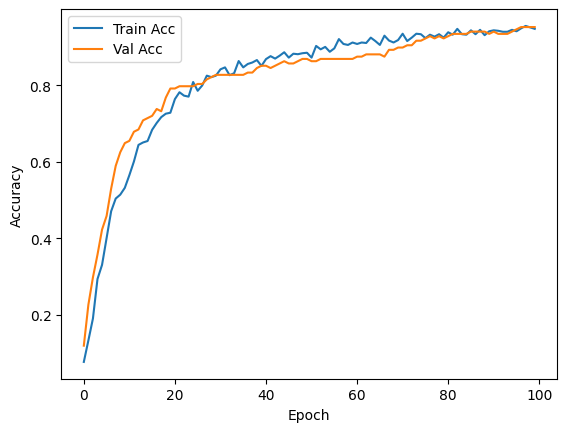

In [13]:
# === Import library untuk CNN ===
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Parameter dasar
IMG_SIZE = (224, 224)   # ukuran input citra (piksel) sesuai EfficientNet
BATCH_SIZE = 32         # jumlah citra per batch

# -----------------------------
# 1. Muat Dataset (train / val / test)
# -----------------------------
train_ds = image_dataset_from_directory(
    "/content/drive/MyDrive/Skripsi/dataset_roi/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"   # multi-class (one-hot)
)
val_ds = image_dataset_from_directory(
    "/content/drive/MyDrive/Skripsi/dataset_roi/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)
test_ds = image_dataset_from_directory(
    "/content/drive/MyDrive/Skripsi/dataset_roi/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

# Simpan jumlah kelas SEBELUM prefetch (atribut class_names hilang setelah prefetch)
class_names = train_ds.class_names
num_classes = len(class_names)
print("Jumlah kelas:", num_classes, "->", class_names)

# Prefetch untuk mempercepat pelatihan (overlap loading & training)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

# -----------------------------
# 2. Data Augmentation
#    Flip horizontal + rotasi acak 10% + zoom acak 10% -> model lebih robust
# -----------------------------
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),   # cerminkan gambar secara horizontal
    layers.RandomRotation(0.1),         # rotasi acak hingga 10%
    layers.RandomZoom(0.1),             # zoom acak hingga 10%
])

# -----------------------------
# 3. Model CNN (EfficientNetB0)
# -----------------------------
base_model_cnn = EfficientNetB0(
    weights="imagenet",       # bobot awal hasil pelatihan ImageNet (transfer learning)
    include_top=False,         # buang lapisan klasifikasi bawaan
    input_shape=IMG_SIZE + (3,)
)
base_model_cnn.trainable = False   # bekukan base model (freeze) selama transfer learning

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)  # normalisasi khas EfficientNet
x = base_model_cnn(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)     # dropout 30% untuk regularisasi (cegah overfitting)
outputs = layers.Dense(
    num_classes,               # jumlah neuron output = jumlah kelas (dihitung sebelum prefetch)
    activation="softmax"       # softmax untuk klasifikasi multi-kelas
)(x)

model_cnn = models.Model(inputs, outputs)

# -----------------------------
# 4. Compile Model
# -----------------------------
model_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),  # learning rate kecil = stabil
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# -----------------------------
# 5. Train Model (100 epoch, dengan EarlyStopping)
# -----------------------------
history_cnn = model_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[
        # Hentikan pelatihan jika val_loss tidak membaik selama 5 epoch berturut-turut
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=5, restore_best_weights=True
        )
    ]
)

# -----------------------------
# 6. Evaluate
# -----------------------------
test_loss_cnn, test_acc_cnn = model_cnn.evaluate(test_ds)
print(f"Test Accuracy (CNN baseline): {test_acc_cnn:.4f}")   # hasil pada laporan ≈ 0.94 (94%)

# -----------------------------
# 7. Plot Akurasi
# -----------------------------
plt.plot(history_cnn.history["accuracy"], label="Train Acc")
plt.plot(history_cnn.history["val_accuracy"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## 5.2.2 Ekstraksi Fitur dengan CNN + LBP

Menambahkan **Local Binary Pattern (LBP)** sebagai fitur tekstur. Parameter LBP: **radius = 3**, **n_points = 8 × radius = 24**, metode **"uniform"**. Kombinasi LBP + EfficientNet meningkatkan akurasi dari 94% menjadi ≈ **96,45%**.

Found 784 files belonging to 28 classes.
Found 168 files belonging to 28 classes.
Found 168 files belonging to 28 classes.


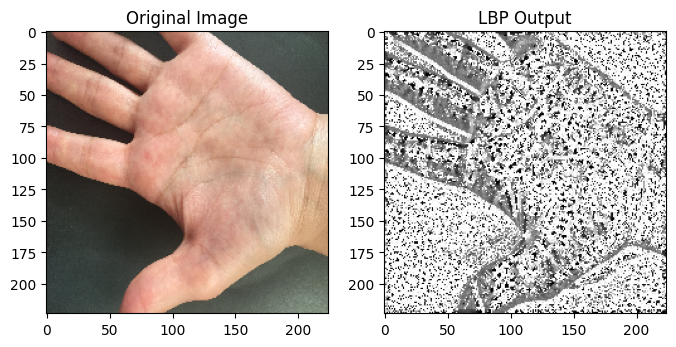

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.0357 - loss: 3.4679 - val_accuracy: 0.0595 - val_loss: 3.3445
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.0548 - loss: 3.2835 - val_accuracy: 0.1310 - val_loss: 3.1786
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.1390 - loss: 3.1074 - val_accuracy: 0.2083 - val_loss: 3.0293
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.2143 - loss: 2.9677 - val_accuracy: 0.3393 - val_loss: 2.8916
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.2934 - loss: 2.8189 - val_accuracy: 0.4226 - val_loss: 2.7629
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.3214 - loss: 2.7185 - val_accuracy: 0.4821 - val_loss: 2.6448
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.4171 - loss: 2.5973 - val_accuracy: 0.5060 - val_loss: 2.5334
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.4630 - loss: 2.4834 - val_accuracy: 0.5833 - v

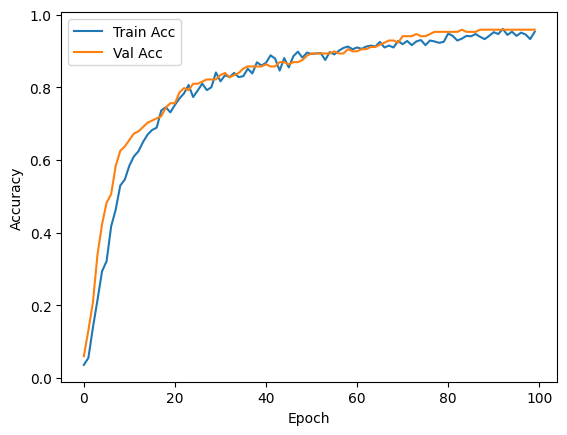

In [15]:
# === Import library untuk CNN + LBP ===
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import cv2
from skimage.feature import local_binary_pattern   # untuk ekstraksi fitur tekstur LBP

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# -----------------------------
# 1. Muat Dataset
# -----------------------------
train_ds = image_dataset_from_directory(
    "/content/drive/MyDrive/Skripsi/dataset_roi/train", image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="categorical"
)
val_ds = image_dataset_from_directory(
    "/content/drive/MyDrive/Skripsi/dataset_roi/val", image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="categorical"
)
test_ds = image_dataset_from_directory(
    "/content/drive/MyDrive/Skripsi/dataset_roi/test", image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="categorical"
)

# Simpan jumlah kelas SEBELUM prefetch (atribut class_names hilang setelah prefetch)
class_names = train_ds.class_names
num_classes = len(class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

# -----------------------------
# 2. Fungsi LBP (Local Binary Pattern)
# -----------------------------
def apply_lbp(image):
    """Menghasilkan citra LBP dari sebuah gambar RGB."""
    # Konversi ke grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    # Parameter LBP
    radius = 3                 # radius lingkaran tetangga
    n_points = 8 * radius      # jumlah titik sampling = 24
    lbp = local_binary_pattern(gray, n_points, radius, method="uniform")
    # Normalisasi nilai LBP ke rentang [0, 255]
    lbp = np.uint8(255 * lbp / lbp.max())
    return lbp

# Contoh: ambil 1 gambar dari dataset dan bandingkan Original vs LBP
for images, labels in train_ds.take(1):
    sample_img = images[0].numpy().astype("uint8")
    lbp_img = apply_lbp(sample_img)

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(sample_img)
    plt.title("Original Image")
    plt.subplot(1, 2, 2)
    plt.imshow(lbp_img, cmap="gray")
    plt.title("LBP Output")
    plt.show()
    break

# -----------------------------
# 3. Model CNN (EfficientNetB0)
# -----------------------------
base_model_lbp = EfficientNetB0(weights="imagenet", include_top=False, input_shape=IMG_SIZE + (3,))
base_model_lbp.trainable = False   # freeze (transfer learning)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base_model_lbp(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
# Jumlah neuron output = jumlah kelas (dihitung sebelum prefetch)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model_lbp = models.Model(inputs, outputs)

# -----------------------------
# 4. Compile & Train
# -----------------------------
model_lbp.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_lbp = model_lbp.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True)]
)

# -----------------------------
# 5. Evaluate
# -----------------------------
test_loss_lbp, test_acc_lbp = model_lbp.evaluate(test_ds)
print(f"Test Accuracy with LBP: {test_acc_lbp:.4f}")   # hasil pada laporan ≈ 0.9645 (96,45%)

# Bandingkan dengan baseline (jika sel CNN sudah dijalankan lebih dulu)
try:
    print(f"Baseline CNN : {test_acc_cnn:.4f}")
    print(f"CNN + LBP    : {test_acc_lbp:.4f}")
except NameError:
    pass

# -----------------------------
# 6. Plot Akurasi
# -----------------------------
plt.plot(history_lbp.history["accuracy"], label="Train Acc")
plt.plot(history_lbp.history["val_accuracy"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

---
# 5.3 Pengujian Sistem

Pengujian dilakukan untuk mengevaluasi performa model identifikasi telapak tangan dan keandalan aplikasi mobile.

## 5.3.1 Pengujian Model (Confusion Matrix)

Menggunakan **confusion matrix** sebagai alat evaluasi utama. Metrik yang dianalisis: **akurasi, precision, recall, dan F1-score**.

Evaluasi: CNN (baseline)


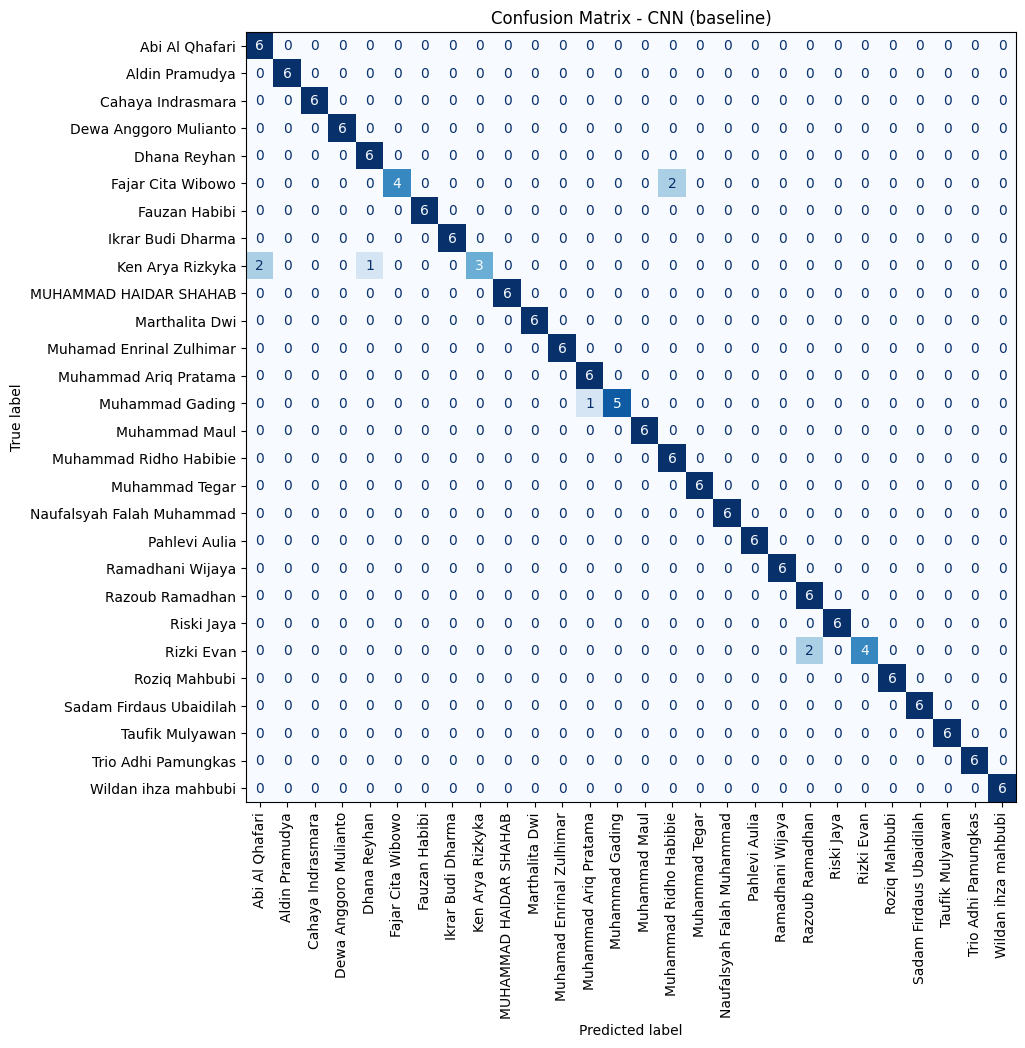

                           precision    recall  f1-score   support

           Abi Al Qhafari       0.75      1.00      0.86         6
           Aldin Pramudya       1.00      1.00      1.00         6
        Cahaya Indrasmara       1.00      1.00      1.00         6
    Dewa Anggoro Mulianto       1.00      1.00      1.00         6
             Dhana Reyhan       0.86      1.00      0.92         6
        Fajar Cita Wibowo       1.00      0.67      0.80         6
            Fauzan Habibi       1.00      1.00      1.00         6
        Ikrar Budi Dharma       1.00      1.00      1.00         6
         Ken Arya Rizkyka       1.00      0.50      0.67         6
   MUHAMMAD HAIDAR SHAHAB       1.00      1.00      1.00         6
           Marthalita Dwi       1.00      1.00      1.00         6
 Muhamad Enrinal Zulhimar       1.00      1.00      1.00         6
    Muhammad Ariq Pratama       0.86      1.00      0.92         6
          Muhammad Gading       1.00      0.83      0.91     

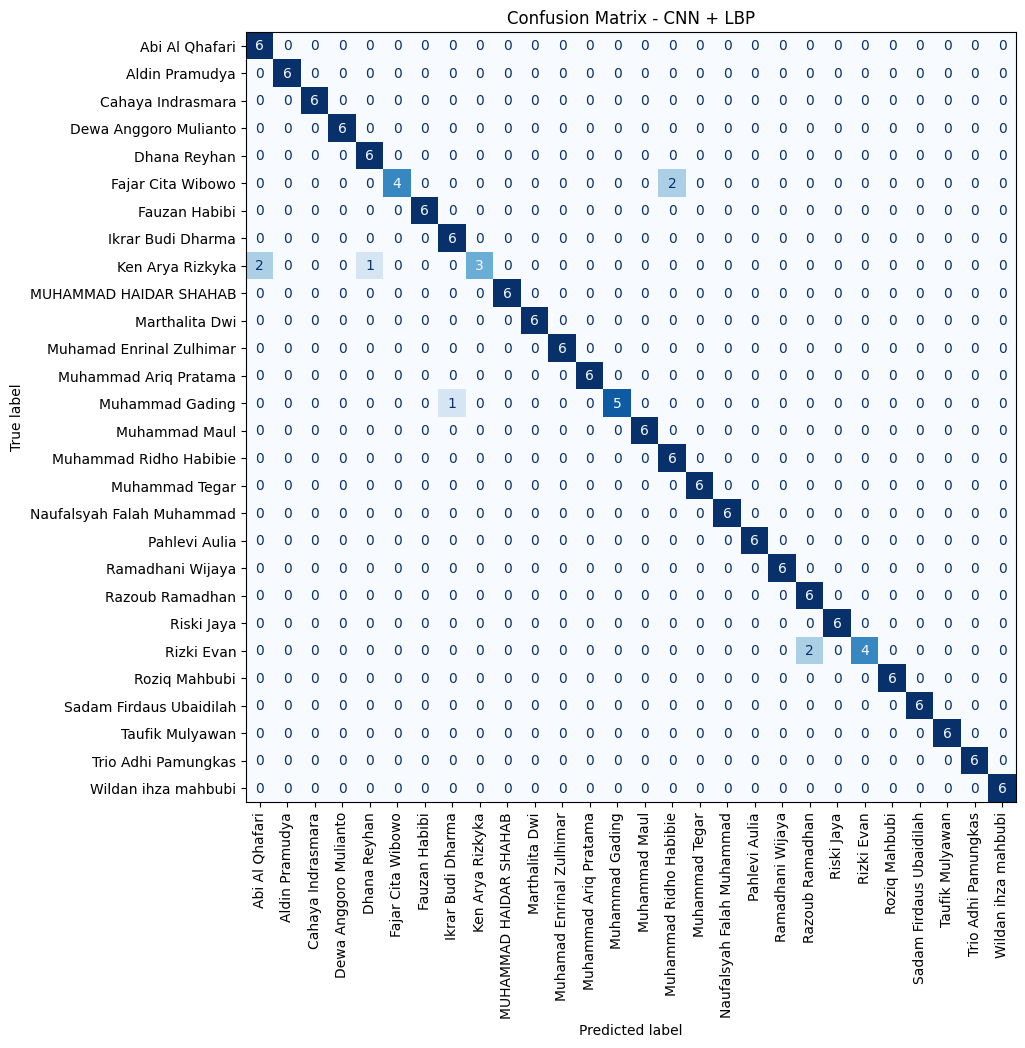

                           precision    recall  f1-score   support

           Abi Al Qhafari       0.75      1.00      0.86         6
           Aldin Pramudya       1.00      1.00      1.00         6
        Cahaya Indrasmara       1.00      1.00      1.00         6
    Dewa Anggoro Mulianto       1.00      1.00      1.00         6
             Dhana Reyhan       0.86      1.00      0.92         6
        Fajar Cita Wibowo       1.00      0.67      0.80         6
            Fauzan Habibi       1.00      1.00      1.00         6
        Ikrar Budi Dharma       0.86      1.00      0.92         6
         Ken Arya Rizkyka       1.00      0.50      0.67         6
   MUHAMMAD HAIDAR SHAHAB       1.00      1.00      1.00         6
           Marthalita Dwi       1.00      1.00      1.00         6
 Muhamad Enrinal Zulhimar       1.00      1.00      1.00         6
    Muhammad Ariq Pratama       1.00      1.00      1.00         6
          Muhammad Gading       1.00      0.83      0.91     

In [16]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 0. Daftar model yang akan diuji (keduanya, tidak memilih salah satu)
# -----------------------------
models_to_test = {
    "CNN (baseline)": model_cnn,
    "CNN + LBP": model_lbp,
}

# Nama kelas: pakai variabel global 'class_names' (disimpan sebelum prefetch).
# Fallback ke atribut test_ds jika masih tersedia.
labels_kelas = class_names if "class_names" in globals() else getattr(test_ds, "class_names", None)

# -----------------------------
# Fungsi bantu: hitung prediksi, tampilkan confusion matrix & classification report
# -----------------------------
def evaluasi_model(nama, model):
    print("=" * 60)
    print(f"Evaluasi: {nama}")
    print("=" * 60)

    # 1. Kumpulkan label sebenarnya (y_true) dan prediksi model (y_pred)
    y_true, y_pred = [], []
    for images, lbls in test_ds:
        preds = model.predict(images, verbose=0)
        y_true.extend(np.argmax(lbls.numpy(), axis=1))   # label asli (dari one-hot)
        y_pred.extend(np.argmax(preds, axis=1))          # kelas prediksi (probabilitas tertinggi)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # 2. Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_kelas)
    fig, ax = plt.subplots(figsize=(10, 10))
    disp.plot(ax=ax, cmap="Blues", xticks_rotation="vertical", colorbar=False)
    plt.title(f"Confusion Matrix - {nama}")
    plt.show()

    # 3. Classification Report (precision, recall, F1-score, akurasi)
    print(classification_report(y_true, y_pred, target_names=labels_kelas))

    return y_true, y_pred

# -----------------------------
# Jalankan evaluasi untuk KEDUA model
# -----------------------------
hasil = {}
for nama, m in models_to_test.items():
    hasil[nama] = evaluasi_model(nama, m)

In [17]:
from google.colab import drive
drive.mount("/content/drive")

# Simpan langsung ke Drive
SAVE_DIR = "/content/drive/MyDrive/Skripsi/models"
import os
os.makedirs(SAVE_DIR, exist_ok=True)

model_cnn.save(os.path.join(SAVE_DIR, "model_cnn.keras"))
model_lbp.save(os.path.join(SAVE_DIR, "model_lbp.keras"))
print("Model tersimpan di Drive:", SAVE_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model tersimpan di Drive: /content/drive/MyDrive/Skripsi/models
